### 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

C:\anaconda3\envs\sound\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
articles = pd.read_csv("our_datasets/LT_datasets/respublika_articles.csv")
comments = pd.read_csv("our_datasets/LT_datasets/respublika_comments.csv")

# Ensure timestamps are datetime
comments["created_at"] = pd.to_datetime(comments["created_at"])

# Pick ONE article for case study
ARTICLE_ID = articles["article_id"].iloc[796]

article_text = articles.loc[
    articles["article_id"] == ARTICLE_ID, "article_content"
].values[0]

article_comments = comments[
    comments["article_id"] == ARTICLE_ID
].sort_values("created_at")

print("Comments:", len(article_comments))

Comments: 455


In [15]:
embedder = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

### FIGURE 2 — Semantic Similarity to Article Over Time

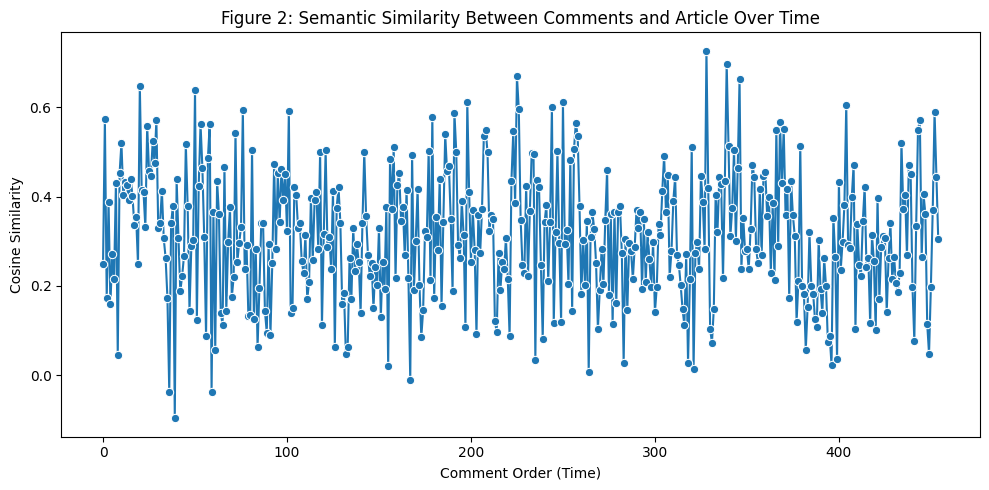

In [16]:
# Embed article
article_emb = embedder.encode([article_text])

# Embed comments
comment_texts = article_comments["comment"].astype(str).tolist()
comment_embs = embedder.encode(comment_texts)

# Cosine similarity
similarities = cosine_similarity(comment_embs, article_emb).flatten()

article_comments["similarity"] = similarities
article_comments["comment_id"] = range(len(article_comments))

plt.figure(figsize=(10, 5))
sns.lineplot(
    x="comment_id",
    y="similarity",
    data=article_comments,
    marker="o"
)

plt.title("Figure 2: Semantic Similarity Between Comments and Article Over Time")
plt.xlabel("Comment Order (Time)")
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.show()

### FIGURE 3 — Emotion Shift Before vs After Deviation

In [17]:
import ruptures as rpt

signal = article_comments["similarity"].values

algo = rpt.Pelt(model="rbf").fit(signal)
change_points = algo.predict(pen=5)

print("Detected change points:", change_points)

split_point = change_points[0] if change_points else len(signal) // 2

before = article_comments.iloc[:split_point]
after = article_comments.iloc[split_point:]

Detected change points: [455]


Device set to use cpu


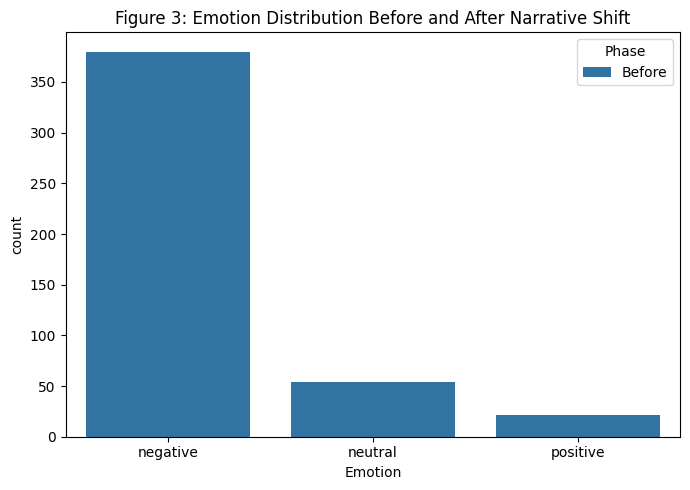

In [18]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

def get_sentiment(texts):
    labels = []
    for t in texts:
        try:
            res = sentiment_model(t[:512])[0]["label"]
            labels.append(res)
        except:
            labels.append("neutral")
    return labels

before_sent = get_sentiment(before["comment"].tolist())
after_sent = get_sentiment(after["comment"].tolist())

sent_df = pd.DataFrame({
    "Emotion": before_sent + after_sent,
    "Phase": ["Before"] * len(before_sent) + ["After"] * len(after_sent)
})

plt.figure(figsize=(7, 5))
sns.countplot(data=sent_df, x="Emotion", hue="Phase")
plt.title("Figure 3: Emotion Distribution Before and After Narrative Shift")
plt.tight_layout()
plt.show()

### FIGURE 4 — Narrative Clusters (UMAP + HDBSCAN)

In [42]:
import umap
import hdbscan

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

comment_umap = umap_model.fit_transform(comment_embs)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=5
)

clusters = clusterer.fit_predict(comment_umap)

article_comments["cluster"] = clusters

C:\anaconda3\envs\sound\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


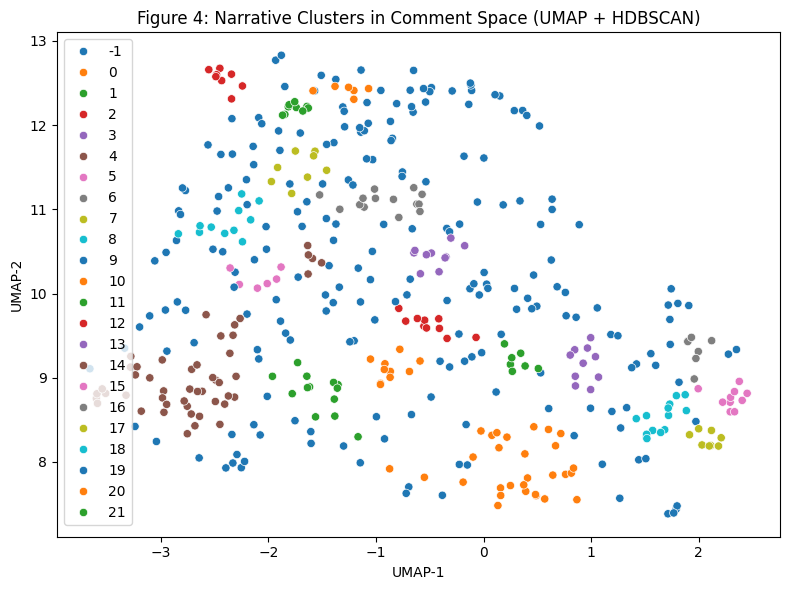

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=comment_umap[:, 0],
    y=comment_umap[:, 1],
    hue=clusters,
    palette="tab10",
    legend="full"
)

plt.title("Figure 4: Narrative Clusters in Comment Space (UMAP + HDBSCAN)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

### Comment–Article Semantic Similarity Over Time (All Articles, Batch Processing)

In [16]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

C:\anaconda3\envs\sound\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
# Load Articles & Comments
articles = pd.read_csv("our_datasets/LT_datasets/respublika_articles.csv")
comments = pd.read_csv("our_datasets/LT_datasets/respublika_comments.csv")

# Ensure timestamps
comments["created_at"] = pd.to_datetime(comments["created_at"])

print("Articles:", articles.shape)
print("Comments:", comments.shape)

Articles: (2783, 8)
Comments: (180086, 9)


In [18]:
# Load Multilingual Embedding Model
embedder = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

In [20]:
# Precompute Article Embeddings (Efficient)
articles["article_embedding"] = list(
    embedder.encode(
        articles["article_content"].astype(str).tolist(),
        show_progress_bar=True
    )
)

Batches: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87/87 [01:10<00:00,  1.23it/s]


In [21]:
# Compute Comment–Article Similarity for ALL Articles
results = []

for _, article in articles.iterrows():
    article_id = article["article_id"]
    article_emb = np.array(article["article_embedding"]).reshape(1, -1)

    article_comments = comments[
        comments["article_id"] == article_id
    ].sort_values("created_at")

    if len(article_comments) == 0:
        continue

    comment_texts = article_comments["comment"].astype(str).tolist()
    comment_embs = embedder.encode(comment_texts)

    similarities = cosine_similarity(comment_embs, article_emb).flatten()

    for idx, row in article_comments.iterrows():
        results.append({
            "article_id": article_id,
            "created_at": row["created_at"],
            "comment": row["comment"],
            "similarity": similarities[list(article_comments.index).index(idx)]
        })

similarity_df = pd.DataFrame(results)

print("Computed similarities:", similarity_df.shape)
similarity_df.head()

Computed similarities: (180086, 4)


,article_id,created_at,comment,similarity
0,87236589,2025-12-08 20:14:33,Prancuzijoje mus vezdavo imones autobusiuku. N...,0.330239
1,87236589,2025-12-08 20:31:37,Daniškas Gamle Olle.,0.182085
2,87236589,2025-12-08 20:58:32,sovietmečiu rambyno sūris labai pikantišku kva...,0.770332
3,87236589,2025-12-08 21:02:24,"Bet kuri nacionalinė virtuvė garsėja tuo, kas ...",0.576039
4,87236589,2025-12-08 21:06:18,Lietuviški sūriai ne tik be kvapo bet ir be sk...,0.727358


In [22]:
# Add Normalized Comment Order (for Time Plots)
similarity_df["comment_order"] = (
    similarity_df
    .groupby("article_id")
    .cumcount()
)

In [23]:
# Per-Article Summary Statistics (Table for Paper)
article_stats = (
    similarity_df
    .groupby("article_id")
    .agg(
        n_comments=("similarity", "count"),
        mean_similarity=("similarity", "mean"),
        std_similarity=("similarity", "std"),
        min_similarity=("similarity", "min"),
        max_similarity=("similarity", "max")
    )
    .reset_index()
)

article_stats.head()

,article_id,n_comments,mean_similarity,std_similarity,min_similarity,max_similarity
0,87235745,16,0.354262,0.125038,0.153428,0.565140
1,87236417,28,0.338493,0.132308,0.131921,0.569339
2,87236589,22,0.458019,0.242219,0.025113,0.795302
3,87237127,14,0.329153,0.175200,0.093771,0.613168
4,87237265,11,0.263536,0.186105,0.025746,0.539708


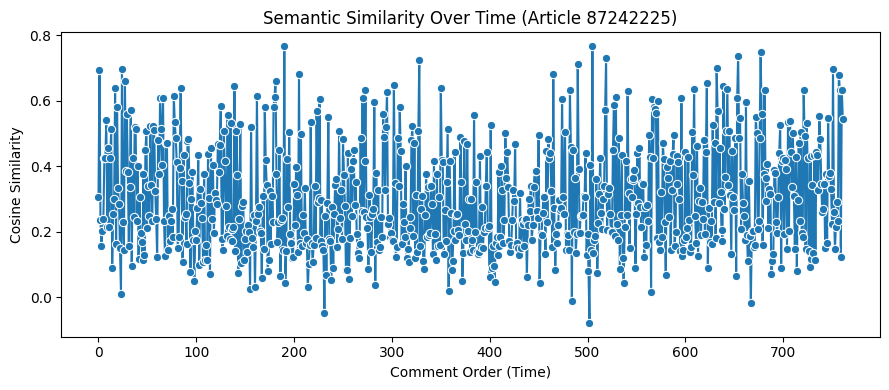

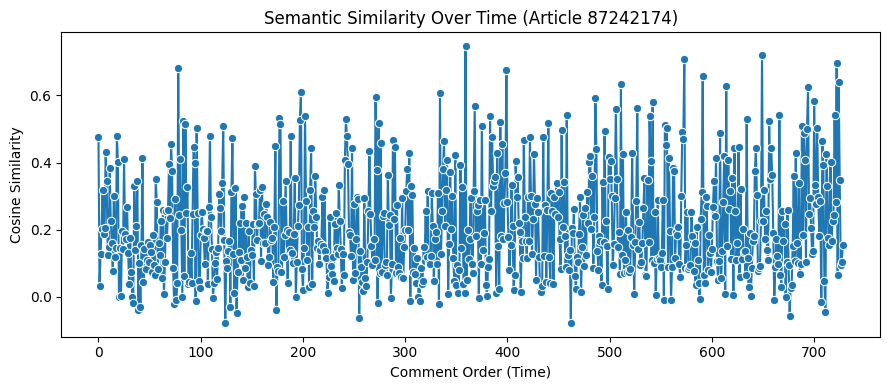

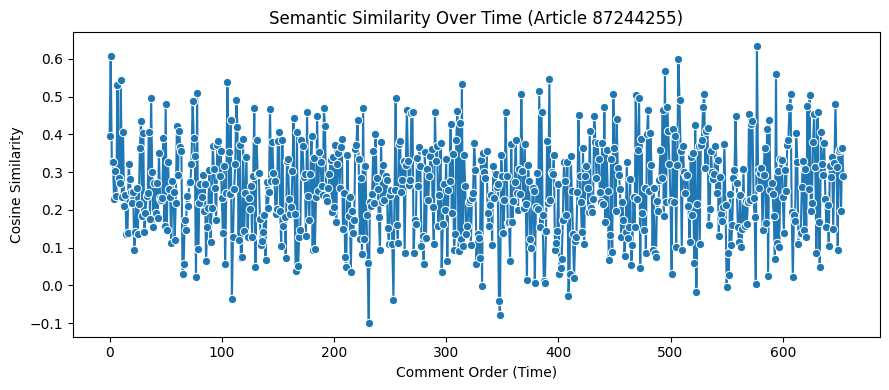

In [24]:
# Figure: Similarity Over Time (Multiple Articles) 
# Option A — Individual Articles (Recommended)
sample_articles = article_stats.sort_values(
    "n_comments", ascending=False
).head(3)["article_id"]

for aid in sample_articles:
    subset = similarity_df[similarity_df["article_id"] == aid]

    plt.figure(figsize=(9, 4))
    sns.lineplot(
        data=subset,
        x="comment_order",
        y="similarity",
        marker="o"
    )

    plt.title(f"Semantic Similarity Over Time (Article {aid})")
    plt.xlabel("Comment Order (Time)")
    plt.ylabel("Cosine Similarity")
    plt.tight_layout()
    plt.show()

C:\Users\tom\AppData\Local\Temp\ipykernel_18764\3187651319.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


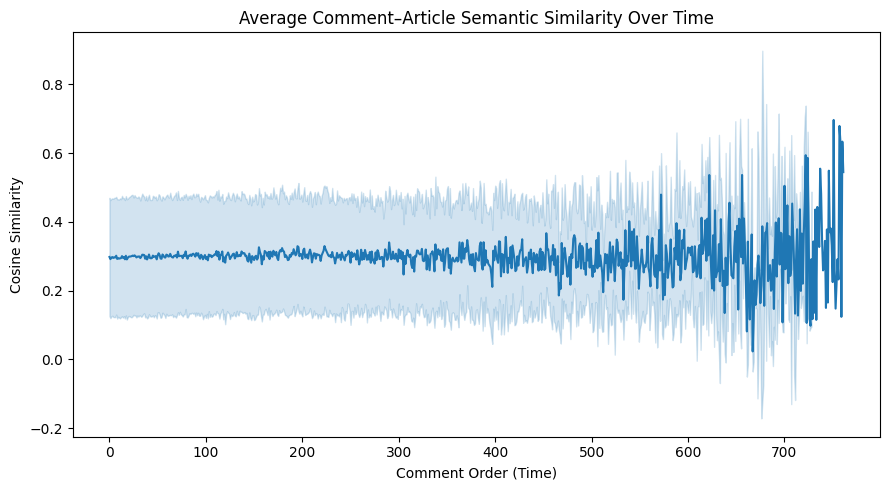

In [25]:
# Option B — Aggregated Trend (Across All Articles)
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=similarity_df,
    x="comment_order",
    y="similarity",
    ci="sd"
)

plt.title("Average Comment–Article Semantic Similarity Over Time")
plt.xlabel("Comment Order (Time)")
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.show()

In [26]:
# Optional: Save Results for Later Analysis
similarity_df.to_csv(
    "comment_article_similarity_all_articles.csv",
    index=False
)

article_stats.to_csv(
    "article_similarity_summary.csv",
    index=False
)

In [27]:
import ruptures as rpt
# Detect Change Points per Article
def detect_change_points(sim_values, pen=5):
    """
    Detect change points in a 1D similarity signal.
    Returns list of indices.
    """
    if len(sim_values) < 10:
        return []

    algo = rpt.Pelt(model="rbf").fit(sim_values)
    change_points = algo.predict(pen=pen)

    # Remove final index (end of signal)
    return [cp for cp in change_points if cp < len(sim_values)]

In [28]:
# Apply to All Articles
change_point_results = []

for article_id, group in similarity_df.groupby("article_id"):
    sim_values = group.sort_values("comment_order")["similarity"].values
    cps = detect_change_points(sim_values, pen=5)

    for cp in cps:
        change_point_results.append({
            "article_id": article_id,
            "change_point_index": cp,
            "relative_position": cp / len(sim_values)
        })

change_points_df = pd.DataFrame(change_point_results)
change_points_df.head()

,article_id,change_point_index,relative_position
0,87237854,185,0.295056
1,87237854,590,0.940989
2,87239093,90,0.379747
3,87239093,170,0.717300
4,87240415,110,0.748299


In [29]:
# Change Point Summary (Table for Paper)
cp_summary = (
    change_points_df
    .groupby("article_id")
    .agg(
        n_change_points=("change_point_index", "count"),
        first_change_pct=("relative_position", "min")
    )
    .reset_index()
)

cp_summary.head()

,article_id,n_change_points,first_change_pct
0,87237854,2,0.295056
1,87239093,2,0.379747
2,87240415,1,0.748299
3,87241474,1,0.625000
4,87243164,1,0.253807


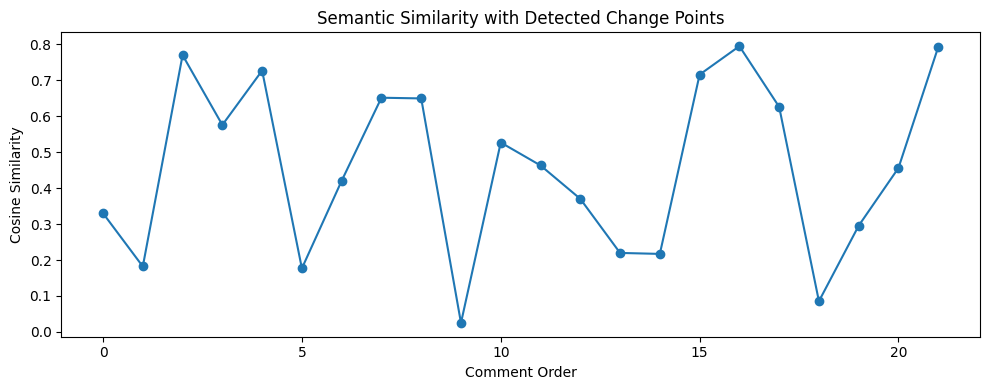

In [33]:
# Visualization (Single Article Example)
example_article = similarity_df["article_id"].iloc[0]
subset = similarity_df[similarity_df["article_id"] == example_article]

plt.figure(figsize=(10, 4))
plt.plot(subset["comment_order"], subset["similarity"], marker="o")

cps = change_points_df[
    change_points_df["article_id"] == example_article
]["change_point_index"]

for cp in cps:
    plt.axvline(cp, color="red", linestyle="--", alpha=0.7)

plt.title("Semantic Similarity with Detected Change Points")
plt.xlabel("Comment Order")
plt.ylabel("Cosine Similarity")
plt.tight_layout()
plt.show()

In [43]:
# article_comments dataframe had cluster labels earlier
# Merge cluster labels into similarity_df

cluster_cols = ["article_id", "created_at", "comment", "cluster"]

similarity_cluster_df = similarity_df.merge(
    article_comments[cluster_cols],
    on=["article_id", "created_at", "comment"],
    how="left"
)

similarity_cluster_df.head()

,article_id,created_at,comment,similarity,comment_order,cluster
0,87236589,2025-12-08 20:14:33,Prancuzijoje mus vezdavo imones autobusiuku. N...,0.330239,0,NaN
1,87236589,2025-12-08 20:31:37,Daniškas Gamle Olle.,0.182085,1,NaN
2,87236589,2025-12-08 20:58:32,sovietmečiu rambyno sūris labai pikantišku kva...,0.770332,2,NaN
3,87236589,2025-12-08 21:02:24,"Bet kuri nacionalinė virtuvė garsėja tuo, kas ...",0.576039,3,NaN
4,87236589,2025-12-08 21:06:18,Lietuviški sūriai ne tik be kvapo bet ir be sk...,0.727358,4,NaN


In [44]:
# Cluster-Level Statistics (CORE TABLE)
cluster_stats = (
    similarity_cluster_df
    .query("cluster != -1")
    .groupby(["article_id", "cluster"])
    .agg(
        cluster_size=("similarity", "count"),
        mean_similarity=("similarity", "mean"),
        std_similarity=("similarity", "std"),
        min_similarity=("similarity", "min"),
        first_comment_order=("comment_order", "min")
    )
    .reset_index()
)

cluster_stats["first_appearance_pct"] = (
    cluster_stats["first_comment_order"] /
    similarity_cluster_df.groupby("article_id")["comment_order"].max().values[0]
)

cluster_stats.head()

,article_id,cluster,cluster_size,mean_similarity,std_similarity,min_similarity,first_comment_order,first_appearance_pct
0,87244477,0.0,54,0.126251,0.095781,-0.056771,1,0.066667
1,87244477,1.0,28,0.459249,0.097987,0.302850,0,0.000000


In [45]:
# Identify Potential Narrative Injection Clusters
global_mean_similarity = similarity_df["similarity"].mean()

cluster_stats["low_alignment"] = (
    cluster_stats["mean_similarity"] < global_mean_similarity
)

cluster_stats["late_emergence"] = (
    cluster_stats["first_appearance_pct"] > 0.3
)

cluster_stats["potential_injection"] = (
    cluster_stats["low_alignment"] & cluster_stats["late_emergence"]
)

cluster_stats.sort_values("mean_similarity").head()

,article_id,cluster,cluster_size,mean_similarity,std_similarity,min_similarity,first_comment_order,first_appearance_pct,low_alignment,late_emergence,potential_injection
0,87244477,0.0,54,0.126251,0.095781,-0.056771,1,0.066667,True,False,False
1,87244477,1.0,28,0.459249,0.097987,0.302850,0,0.000000,False,False,False


In [46]:
# Injection Summary (VERY IMPORTANT TABLE)
injection_summary = (
    cluster_stats
    .groupby("article_id")
    .agg(
        n_clusters=("cluster", "count"),
        n_potential_injection=("potential_injection", "sum")
    )
    .reset_index()
)

injection_summary.head()

,article_id,n_clusters,n_potential_injection
0,87244477,2,0


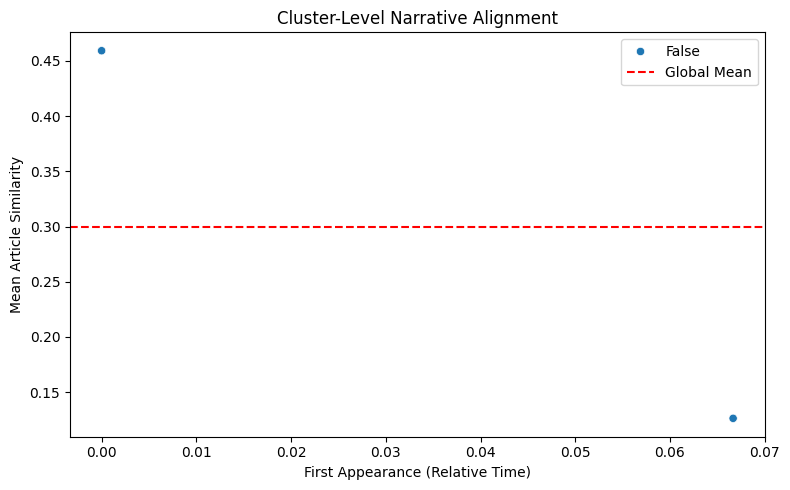

In [47]:
# Optional Visualization: Cluster Alignment vs Time
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=cluster_stats,
    x="first_appearance_pct",
    y="mean_similarity",
    hue="potential_injection",
    style="potential_injection"
)

plt.axhline(global_mean_similarity, color="red", linestyle="--", label="Global Mean")
plt.xlabel("First Appearance (Relative Time)")
plt.ylabel("Mean Article Similarity")
plt.title("Cluster-Level Narrative Alignment")
plt.legend()
plt.tight_layout()
plt.show()

# TMP - Remove rows in csv

In [57]:
import pandas as pd

# ----------------------------
# Configuration
# ----------------------------
input_csv = "respublika_comments.csv"      # path to your CSV file respublika_articles | respublika_comments | 1000=65830 | 100=6513 | 10=269
output_csv = "respublika10_comments.csv"    # path for cleaned CSV
start_row = 269             # row index to start removing (0-based)

# Read CSV (explicit UTF-8 is also good practice)
df = pd.read_csv(input_csv, encoding="utf-8")

# Keep rows before start_row
df_cleaned = df.iloc[:start_row]

# Save with UTF-8 BOM so Excel keeps Lithuanian letters
df_cleaned.to_csv(
    output_csv,
    index=False,
    encoding="utf-8-sig"
)

print("Saved with Lithuanian characters preserved ✅")

Saved with Lithuanian characters preserved ✅


In [11]:
import pandas as pd

# Path to your CSV file
csv_file = "delfi_comments_fixed.csv"

# Read CSV (explicit UTF-8 is safe)
df = pd.read_csv(csv_file, encoding="utf-8")

# Display first 5 rows
df.head()

print(df.head(5))

  article_id comment_id   username  \
0  120201928  300491980   Timudzin   
1  120201928  300491975  Tomas2026   
2  120201928  300491884   p Vaidas   
3  120202093  300491898  gedas0791   
4  120202012  300491883       Wind   

                                             comment  \
0  Šitas iš charakterio tai lenktynininkų J. Stat...   
1  Nežinau kaip jums, man jis nepatinka. Žala va ...   
2                                Puikus pasirodymas!   
3  Iš amerikiečių pusės bus Vitek ir žentelis. Iš...   
4  Galima iškar ją pašalinti, lyčių lygybės minis...   

                  created_at is_reply parent_ref reactions_angry  \
0  2026-01-22T21:40:59+02:00    False        NaN               0   
1  2026-01-22T21:37:42+02:00    False        NaN               0   
2  2026-01-22T20:26:28+02:00    False        NaN               0   
3  2026-01-22T20:34:24+02:00    False        NaN               0   
4  2026-01-22T20:25:54+02:00    False        NaN               0   

  reactions_dislike react

In [12]:
import pandas as pd

# ----------------------------
# Configuration
# ----------------------------
input_csv = "my_dataset/delfi_comments.csv"
output_csv = "my_dataset/delfi_comments_cleaned.csv"

# ----------------------------
# Read CSV safely
# ----------------------------
df = pd.read_csv(
    input_csv,
    encoding="utf-8",
    dtype=str,          # read everything as string to avoid corruption issues
    on_bad_lines="skip" # skip badly formatted rows
)

print(f"Original rows: {len(df)}")

# ----------------------------
# Normalize is_reply column
# ----------------------------
# Strip spaces and convert to uppercase
df["is_reply"] = df["is_reply"].str.strip().str.upper()

# ----------------------------
# Keep only valid rows (TRUE or FALSE)
# ----------------------------
df_cleaned = df[df["is_reply"].isin(["TRUE", "FALSE"])]

print(f"Clean rows kept: {len(df_cleaned)}")

# ----------------------------
# Save cleaned CSV (Excel-safe)
# ----------------------------
df_cleaned.to_csv(
    output_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"Cleaned file saved as: {output_csv}")

Original rows: 11913
Clean rows kept: 11792
Cleaned file saved as: my_dataset/delfi_comments_cleaned.csv


In [18]:
import pandas as pd

# ----------------------------
# Configuration
# ----------------------------
input_csv = "my_dataset/delfi_articles.csv"
output_csv = "my_dataset/delfi_articles_cleaned.csv"

# ----------------------------
# Read CSV safely (handles corruption)
# ----------------------------
df = pd.read_csv(
    input_csv,
    encoding="utf-8",
    dtype=str,          # read everything as string to avoid parsing errors
    on_bad_lines="skip" # skip badly broken rows
)

print(f"Original rows: {len(df)}")

# ----------------------------
# Normalize article_id column
# ----------------------------
df["article_id"] = df["article_id"].str.strip()

# ----------------------------
# Keep only rows where article_id is a number
# ----------------------------
df_cleaned = df[df["article_id"].str.fullmatch(r"\d+")]

print(f"Clean rows kept: {len(df_cleaned)}")

# ----------------------------
# (Optional) convert article_id to integer
# ----------------------------
df_cleaned["article_id"] = df_cleaned["article_id"].astype(int)

# ----------------------------
# Save cleaned CSV (Excel-safe)
# ----------------------------
df_cleaned.to_csv(
    output_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"Cleaned file saved as: {output_csv}")


Original rows: 1311
Clean rows kept: 1311
Cleaned file saved as: my_dataset/delfi_articles_cleaned.csv


In [17]:
import pandas as pd

# ----------------------------
# Configuration
# ----------------------------
input_csv = "my_dataset/delfi_articles.csv"
output_csv = "my_dataset/delfi_articles_clean.csv"

# ----------------------------
# Read CSV
# ----------------------------
df = pd.read_csv(input_csv, encoding="utf-8")

# ----------------------------
# Parse datetime and REMOVE timezone WITHOUT shifting time
# ----------------------------
df["published_at"] = (
    pd.to_datetime(df["published_at"])   # parse ISO string with +02:00
      .dt.tz_localize(None)               # REMOVE timezone, keep clock time
      .dt.strftime("%Y-%m-%d %H:%M:%S")
)

# ----------------------------
# Save cleaned CSV
# ----------------------------
df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print("Saved cleaned file without time shift:", output_csv)


Saved cleaned file without time shift: my_dataset/delfi_articles_clean.csv
